# 加入高程後的空間 Gaussian Process 模型診斷與比較

本 notebook 用於檢驗：在目前只使用平面座標的 Gaussian Process（GP）
中加入 GRID 高程，是否能改善神經網路估計之 GEV 參數曲面的空間預測。

分析不直接窮舉所有 GP，而採用下列順序：

1. 先建立可解釋的 baseline；
2. 用 trend residual、directional variogram、elevation-band local
   variogram 及 parametric simulation envelope 篩選候選結構；
3. 只把有診斷或研究機制支持的結構列入候選計畫；
4. 所有已實作候選模型使用相同 buffered spatial folds，且每一 fold
   重新估計 covariance parameters；
5. 最後以 OOF residual 與預測校準判斷模型是否已經足夠。

目前已實作的核心比較為：

$$
T_0:\quad y(s)=\beta_0+w(s)+\epsilon(s),
$$

$$
T_1:\quad
y(s)=\beta_0+\beta_1\,\operatorname{Elevation}(s)
+w(s)+\epsilon(s).
$$

其中 response 為：

$$
y(s)\in
\left\{
\hat\mu(s),\;
\widehat{\log\sigma}(s),\;
\hat\xi(s)
\right\}.
$$

baseline screening 使用 linear-elevation mean 與 stationary isotropic
Matérn($\nu=1.5$)。若診斷要求 nonlinear mean、anisotropy、
elevation-dependent range/variance 或 spatial-elevation distance，
本 notebook 會明確標記為「需擴充候選模型」，不會把目前八個核心模型
誤稱為已涵蓋所有合理空間結構。

實際的資料處理、GP 計算、診斷、Spatial CV 與 return-level 函式放在
`experiments/window_data/src/elevation_gp_analysis.py`。


## 研究判斷原則

- 診斷不是直接選出最終模型，而是限制「值得比較的候選集合」。
- baseline 是 T1 + stationary isotropic Matérn($\nu=1.5$)；
  診斷在相同觀測位置下以 parametric simulation 建立 95% 上界。
- observed diagnostic statistic 超過 simulation 95% 上界，只表示
  相應的擴充模型應進入候選集合，不代表擴充模型一定較好。
- 連續 covariance parameters（variance、range、nugget）必須在每個
  spatial-CV training fold 內重新估計，不可先用完整資料估計後固定。
- Buffered spatial CV 是主要選模證據；AIC/BIC 是樣本內支持證據。
- 最終模型還需通過 OOF residual map、Moran's I、residual variogram
  與 prediction calibration，才能稱為「對目前目的足夠」。
- 若診斷要求的模型尚未實作，現有 T0/T1×kernel 結果只能視為
  provisional core comparison。


## 完整分析的 Block 邏輯

| Block | 輸入 | 核心處理 | 輸出與判斷用途 |
|---|---|---|---|
| 0 | 路徑與分析參數 | 固定亂數、fold、buffer、診斷模擬次數與計算上限 | 確保流程可重現 |
| 1 | NN-derived GEV 表與高程表 | 一對一合併並稽核 | 取得完整分析表 |
| 2 | 高程與三個 GEV parameters | correlation、散佈圖與高程地圖 | 初步了解 mean 關係，不作最終選模 |
| 3 | 投影後座標 | 建立所有模型共用的 geographic folds | 固定後續比較設計 |
| 4 | T1 + stationary isotropic Matérn(1.5) baseline | trend residual、directional/local variograms、simulation envelope | 檢查 nonlinear mean、anisotropy、variance/range nonstationarity 與 elevation distance |
| 5 | Block 4 診斷旗標 | 建立 response-specific candidate plan，並列出尚未實作的必要擴充 | 防止任意窮舉或遺漏有證據的模型 |
| 6 | 已實作核心候選模型 | 完整資料 likelihood、AIC、BIC | 評估樣本內支持與複雜度 |
| 7 | 相同 folds 與 response-specific buffer | Buffered spatial 5-fold CV；各 fold 重估參數 | 取得地理留出預測表現 |
| 8 | AIC/BIC 與 Spatial-CV | 選出已實作候選中的最佳模型 | 主要依 Spatial-CV 選模 |
| 9–11 | 最佳模型 OOF residual | residual map、Moran's I、variogram | 檢查剩餘空間結構 |
| 12 | 三個 OOF parameter predictions | RL50、RL100 | 檢查改善是否傳遞到研究量 |
| 13 | 診斷旗標、CV 與 adequacy evidence | 套用停止規則 | 判斷模型已足夠或仍須擴充 |


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

cwd = Path.cwd().resolve()
if (cwd / "experiments" / "window_data" / "data" / "processed").exists():
    WINDOW_ROOT = cwd / "experiments" / "window_data"
elif cwd.name == "window_data" and (cwd / "data" / "processed").exists():
    WINDOW_ROOT = cwd
elif cwd.parent.name == "window_data" and (cwd.parent / "data" / "processed").exists():
    WINDOW_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "請從 experiments/window_data 或其 notebooks 資料夾執行。"
    )

SRC_DIRECTORY = WINDOW_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

from elevation_gp_analysis import (
    build_model_specs,
    calculate_residual_morans_i,
    calculate_residual_variograms,
    compare_return_levels,
    exploratory_elevation_analysis,
    fit_information_criteria,
    load_grid_with_elevation,
    parameter_wise_elevation_tests,
    plot_cv_comparison,
    plot_oof_residual_maps,
    prepare_spatial_folds,
    resolve_analysis_paths,
    return_level_pipeline_tests,
    run_buffered_spatial_cv,
    screen_spatial_assumptions,
    select_models,
)


## 0. 分析設定

本段只放需要由研究者決定的設定。

- `SELECTED_K = 5`：所有候選模型共用的五個 geographic folds。
- `MAX_DIAGNOSTIC_TRAIN`：baseline diagnostic 的可重現樣本上限。
- `N_DIAGNOSTIC_SIMULATIONS`：stationary isotropic baseline 下的
  parametric simulations；正式版本建議至少 199。
- `MAX_BASE_TRAIN = 800`：Exact GP 的訓練樣本上限。
- `BUFFER_KM`：由先前 parameter variogram 與 buffer sensitivity
  analysis 決定，不能看本 notebook 的 test-fold 結果後再調整。
- `N_RESTARTS_AIC` 與 `N_RESTARTS_CV`：optimizer restart 次數。


In [2]:
RANDOM_STATE = 111
SELECTED_K = 5
MAX_DIAGNOSTIC_TRAIN = 500
N_DIAGNOSTIC_SIMULATIONS = 199
N_RESTARTS_DIAGNOSTIC = 0
MAX_BASE_TRAIN = 800
MIN_TRAIN = 100
MORAN_PERMUTATIONS = 999
N_RESTARTS_AIC = 3
N_RESTARTS_CV = 0

BUFFER_KM = {
    "mu": 55.0,
    "log_sigma": 35.0,
    "xi": 30.0,
}

paths = resolve_analysis_paths(Path.cwd())
FIG_DIR = paths["figure_directory"]
TABLE_DIR = paths["table_directory"]

display({
    "GEV 資料": paths["gev_path"],
    "高程資料": paths["elevation_path"],
    "圖檔輸出": FIG_DIR,
    "表格輸出": TABLE_DIR,
})


{'GEV 資料': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/experiments/window_data/data/processed/grid_station_gev_params_with_loc.csv'),
 '高程資料': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/觀測_日資料_臺灣_網格高程/觀測_日資料_臺灣_網格高程.csv'),
 '圖檔輸出': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/experiments/window_data/results/figures'),
 '表格輸出': WindowsPath('C:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/experiments/window_data/results/tables')}

## 1. 讀取、清理並配對高程資料

本步驟僅以四捨五入至小數點後兩位的經緯度作為原始 GRID 配對鍵值，
將 NN-derived GEV parameters 與高程一對一合併。

程式會檢查：

- 原始經緯度鍵值是否重複；
- 每一個 GEV GRID 是否都能配對到高程；
- 高程是否含有負值；
- 合併關係是否確實為 one-to-one。

通過檢查後才允許進入後續模型比較，避免錯誤配對被誤認為高程效果。


In [3]:
data = load_grid_with_elevation(
    gev_path=paths["gev_path"],
    elevation_path=paths["elevation_path"],
    output_path=TABLE_DIR / "grid_station_gev_params_with_elevation.csv",
)

display(data[[
    "station",
    "lon",
    "lat",
    "elevation_m",
    "mu_hat",
    "log_sigma_hat",
    "xi_hat",
]].head())
display(data["elevation_m"].describe().to_frame("value"))

,station,lon,lat,elevation_m,mu_hat,log_sigma_hat,xi_hat
0,G119.45_23.20,119.45,23.20,0.0,31.698334,-1.434958,0.227292
1,G119.50_23.35,119.50,23.35,0.0,31.679490,-1.273440,0.180436
2,G119.50_23.40,119.50,23.40,0.0,31.653676,-1.294992,0.181252
3,G119.50_23.50,119.50,23.50,0.0,31.540771,-1.587916,0.236057
4,G119.50_23.60,119.50,23.60,0.0,31.527162,-1.154317,0.129411


,value
count,1412.000000
mean,711.761615
std,844.791312
min,0.000000
25%,31.000000
50%,319.000000
75%,1176.250000
max,3550.000000


### Block 1 結果解讀：資料配對與高程分布

- 1,412 個 NN-derived GEV GRID 全部成功配對高程，沒有缺失值，因此後續 T0 與 T1 使用完全相同的 GRID 樣本。
- 高程範圍為 0 至 3,550 m，中位數為 319 m，平均數為 711.76 m。
- 平均數高於中位數，表示高程分布右偏：多數 GRID 位於低海拔，少數中央山區 GRID 延伸至很高的海拔。
- 這一步只證明資料可正確合併，尚不能說高程能改善任何 GEV parameter。


## 2. 高程的探索性檢查

本步驟先畫出高程與三個 NN-derived GEV parameters 的散佈關係，
並計算 Pearson correlation、Spearman correlation、簡單線性斜率與
simple R-squared。

這些結果只能回答「高程是否值得列為候選變數」，不能直接證明因果或
宣稱模型已改善，因為 GRID 之間具有空間相依性，普通 correlation 的
p-value 不能把 1,412 個 GRID 當成完全獨立的樣本。


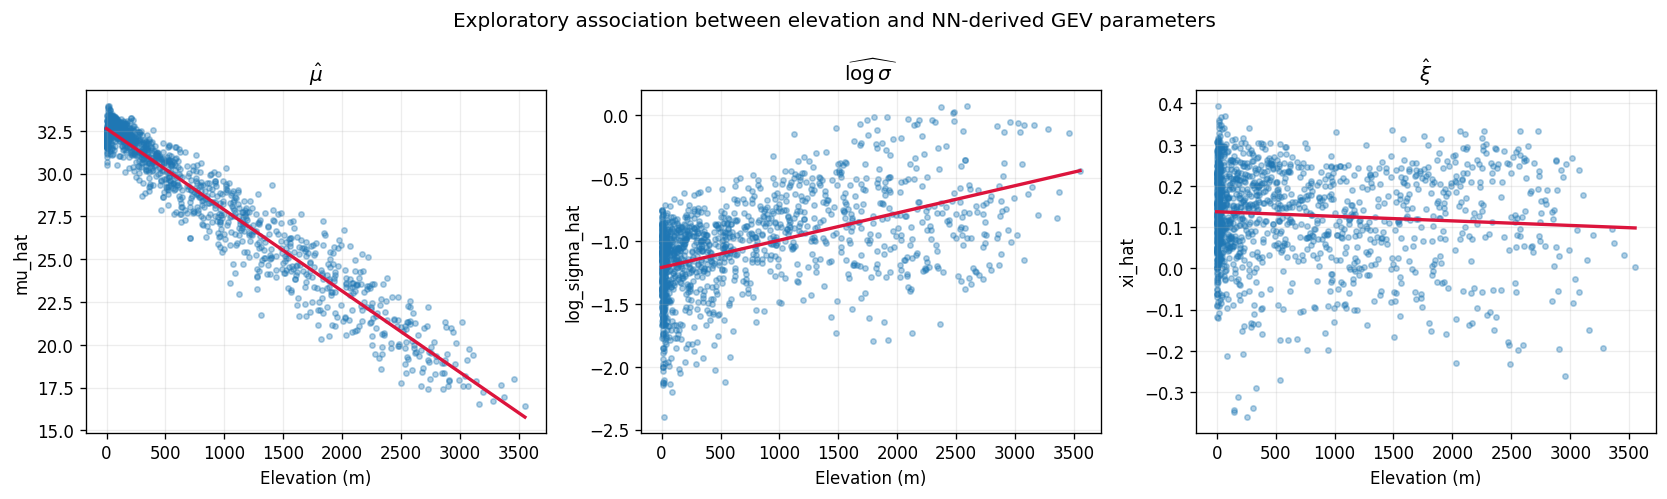

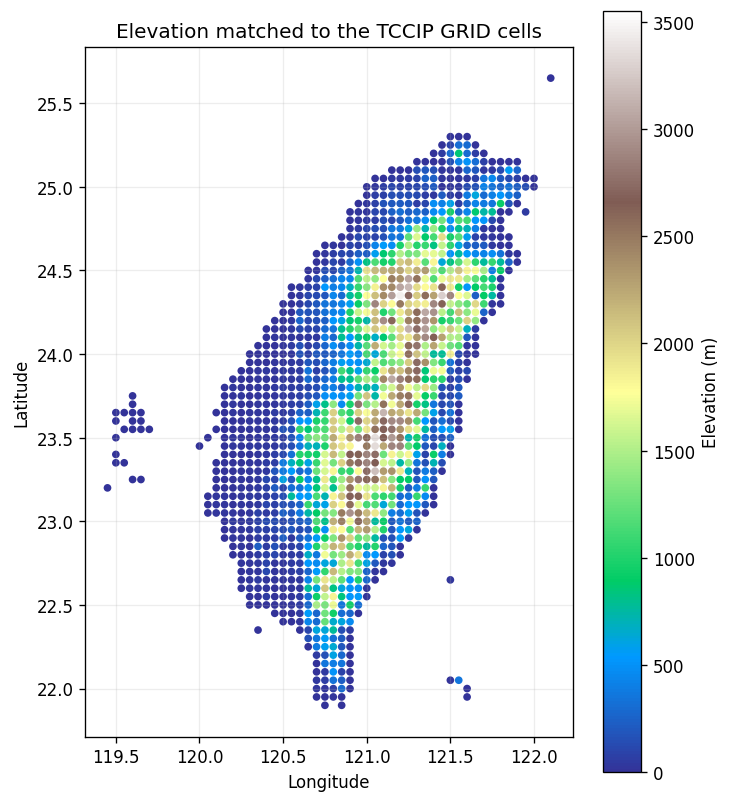

,target,pearson_r,spearman_rho,slope_per_1000m,simple_R2
0,mu,-0.9705,-0.8747,-4.7469,0.9419
1,log_sigma,0.4992,0.4863,0.2169,0.2492
2,xi,-0.0801,-0.0424,-0.0111,0.0064


In [4]:
exploratory_summary, association_figure, elevation_map = (
    exploratory_elevation_analysis(
        data,
        figure_directory=FIG_DIR,
        table_directory=TABLE_DIR,
    )
)
plt.show()
display(exploratory_summary.round(4))

### Block 2 圖表解讀：高程關係圖與高程地圖

**圖一：高程與三個 GEV parameters 的關係**

- location parameter 與高程呈非常強的負向關係；Pearson correlation 為 -0.9705，simple R-squared 為 0.9419。高程每增加 1,000 m，location estimate 平均約下降 4.75 度。這提供高程可能大幅改善 location model 的強烈探索性證據。
- log-scale parameter 與高程呈中度正向關係；Pearson correlation 為 0.4992，simple R-squared 為 0.2492。高程可能解釋部分變異，但散點仍相當分散，表示還有其他空間因素。
- shape parameter 與高程幾乎沒有單純線性或單調關係；Pearson correlation 為 -0.0801，simple R-squared 只有 0.0064。因此不應預先宣稱高程會改善 shape model。

**圖二：1,412 個 GRID 的高程地圖**

- 高海拔 GRID 集中於臺灣中部及中央山脈走向，西部平原與離島多為低海拔，空間圖形符合臺灣地形的基本特徵。
- 高程本身具有很強的空間結構，因此散佈圖的 correlation 只能用來提出候選模型，不能把 1,412 個 GRID 當成獨立樣本作最終推論。


## 3. 建立固定 geographic folds

原始經緯度先轉換成 TWD97 / TM2（EPSG:3826）的 `x_km` 與 `y_km`。
後續 GP、K-means、variogram、buffer 與地圖皆使用公里座標；模型只做平移置中，不分別縮放兩軸，因此 kernel length scale 仍具有 km 的物理意義。
接著以 `x_km`、`y_km` 建立固定的 coordinate-based K-means
五區。診斷、T0/T1 與所有 kernel 候選都使用同一份投影座標。

K-means 只負責形成地理上集中的 test folds，不能消除邊界附近的
train-test 資訊洩漏；真正的隔離由後面的 distance buffer 完成。


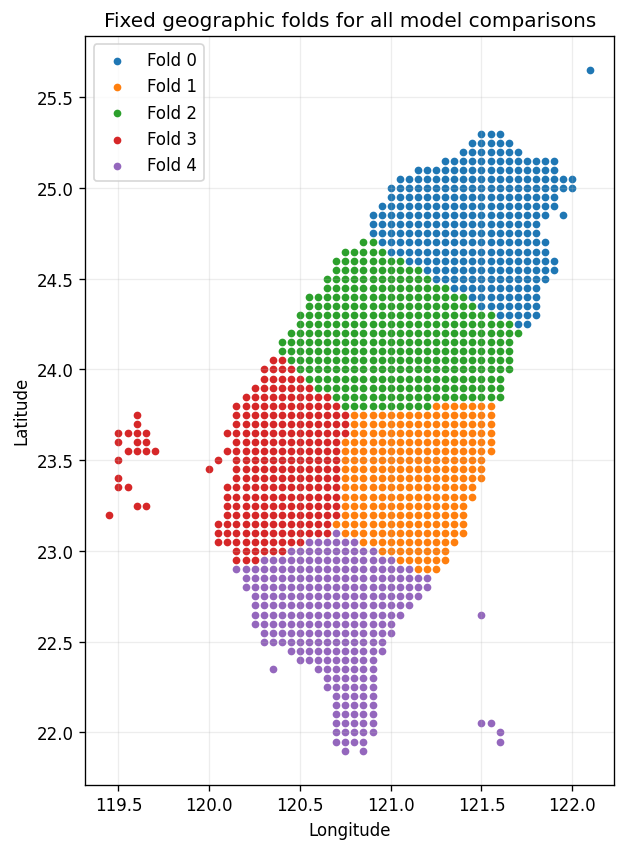

,model_id,trend,kernel,nu
0,T0_RBF_na,T0,RBF,NaN
1,T0_Matern_0p5,T0,Matern,0.5
2,T0_Matern_1p5,T0,Matern,1.5
3,T0_Matern_2p5,T0,Matern,2.5
4,T1_RBF_na,T1,RBF,NaN
5,T1_Matern_0p5,T1,Matern,0.5
6,T1_Matern_1p5,T1,Matern,1.5
7,T1_Matern_2p5,T1,Matern,2.5


,n_grid
spatial_fold,
0,298
1,252
2,333
3,260
4,269


In [5]:
data, fold_figure = prepare_spatial_folds(
    data,
    n_folds=SELECTED_K,
    random_state=RANDOM_STATE,
    figure_path=FIG_DIR / "elevation_03_fixed_spatial_folds.png",
)
plt.show()
display(data.groupby("spatial_fold").size().rename("n_grid").to_frame())


### Block 3 圖表解讀：固定 geographic folds

- 五個 folds 各自形成連續且集中的地理區域，而不是像 Random CV 一樣把相鄰 GRID 隨機分散到 training 與 test。
- 各 fold 樣本數依序為 298、252、333、260、269；最大與最小 fold 並非完全相等，但沒有任何 fold 小到無法作為完整 test region。
- 這張圖只能證明 test folds 具有地理集中性，不能證明 train 與 test 已經空間獨立。相鄰 fold 的邊界仍可能發生 spatial leakage，因此下一階段仍需加入 response-specific distance buffer。
- 所有八個候選模型共用這一組 folds，確保後續 RMSE 差異來自模型，而不是不同切割方式。


## 4. Baseline assumption screening

先對每個 response 擬合：

$$
Y(s)=\beta_0+\beta_1z(s)+w(s)+\epsilon(s),
\qquad
w(s)\sim GP\{\text{stationary isotropic Matérn}(1.5)\}.
$$

診斷使用

$$
r_i^{\mathrm{trend}}=y_i-x_i^\top\hat\beta,
$$

而不是扣除 kriging spatial effect 後的 in-sample residual，避免 GP
把缺少的 covariance 結構吸收掉。對同一組觀測位置，從 fitted baseline
模擬資料並重新估計 mean coefficients，建立各診斷統計量的 95% 上界。

五個 screening gates 為：

| diagnostic | 統計量概念 | 超過 simulation 95% 上界時加入 |
|---|---|---|
| `nonlinear_mean` | linear trend 之外的 degree 2–4 residual curvature | nonlinear elevation mean |
| `anisotropy` | 相同距離 bin 內四方向 semivariance contrast | geometric anisotropy |
| `variance_nonstationarity` | 三個高程帶 residual variance ratio | elevation-dependent variance |
| `range_nonstationarity` | 三個高程帶短距離 normalized semivariance contrast | elevation-dependent range |
| `elevation_distance` | 控制水平距離 bin 後，高程差對 semivariance 的增量 | spatial-elevation distance |

這些是 screening statistics，不是最終模型檢定；正式選擇仍由後續
buffered spatial CV 決定。異方差、range 與 elevation distance 也可能
互相混淆，因此只把它們當作候選模型入口。


In [ ]:
diagnostic_screening, diagnostic_figure = screen_spatial_assumptions(
    data=data,
    max_train=MAX_DIAGNOSTIC_TRAIN,
    n_simulations=N_DIAGNOSTIC_SIMULATIONS,
    n_restarts=N_RESTARTS_DIAGNOSTIC,
    random_state=RANDOM_STATE,
    output_table_path=(
        TABLE_DIR / "elevation_gp_baseline_diagnostic_screening.csv"
    ),
    output_figure_path=(
        FIG_DIR / "elevation_04_baseline_diagnostic_screening.png"
    ),
)
plt.show()
display(
    diagnostic_screening[
        [
            "target",
            "diagnostic",
            "observed_statistic",
            "simulation_q95",
            "flag_candidate",
            "candidate_action",
        ]
    ].round(5)
)


### Block 4 判讀規則

- `flag_candidate = True`：baseline 無法充分重現該診斷統計量，將對應
  結構加入該 response 的候選計畫。
- `False` 代表目前資料沒有足夠證據要求該擴充，不代表數學上證明
  isotropy 或 stationarity 為真。
- directional/local variogram 必須和 simulation flag 一起解讀；
  單一距離 bin 的交叉不作為增加模型的理由。
- diagnostic sample、simulation 次數與亂數種子已固定，避免看結果後
  反覆調整切點。

可參考 Guan、Sherman 與 Calvin 的 nonparametric isotropy test，以及
[Bandyopadhyay and Subba Rao 的 irregular spatial stationarity test](https://academic.oup.com/jrsssb/article/79/1/95/7041917)。


## 5. 由診斷建立 response-specific candidate plan

診斷結果只決定哪些結構值得進入比較。mean 與 covariance 必須分階段處理：若 `nonlinear_mean` 被標記，先改善 mean 並重新執行 screening，再確認其他 covariance flags。為避免組合爆炸：

1. 永遠保留 baseline／核心 T0–T1 比較；
2. 每個被標記的機制先建立一個單一擴充模型；
3. 只有單一擴充在 spatial CV 有穩定改善時，才考慮組合模型；
4. 若必要擴充尚未實作，後面的八模型結果必須標記為 provisional。

目前 GP 程式已實作 T0/T1 mean 與 stationary isotropic
RBF／Matérn kernels；nonlinear mean、anisotropy、nonstationary
variance/range 和 spatial-elevation distance 仍需新增 covariance
parameterization 後才能進入正式比較。


In [ ]:
candidate_plan = diagnostic_screening.loc[
    diagnostic_screening["flag_candidate"],
    ["target", "diagnostic", "candidate_action"],
].copy()
candidate_plan.insert(
    2,
    "diagnostic_stage",
    candidate_plan["diagnostic"].map(
        lambda value: (
            "stage 1: resolve mean first"
            if value == "nonlinear_mean"
            else "stage 2: reconfirm after mean is adequate"
        )
    ),
)
candidate_plan["implementation_status"] = (
    "required extension: not yet in the core GP fitter"
)

if candidate_plan.empty:
    display(Markdown(
        "**診斷結果：** 沒有 screening statistic 超過 baseline "
        "simulation envelope；目前可先保留 stationary isotropic core set。"
    ))
else:
    display(Markdown(
        "**重要：** 下表是診斷要求加入的候選模型。完成這些擴充並一起做 "
        "spatial CV 前，後面的八模型比較只能視為 provisional。"
    ))
    display(candidate_plan)

# 目前可執行的核心候選：研究問題要求的 T0/T1，加上少數固定 kernel。
# 連續的 variance、range、nugget 會在每個 CV training fold 重新估計。
model_specs = build_model_specs()
display(model_specs)


## 6. 以 AIC 與 BIC 比較已實作核心候選模型

本步驟在相同訓練 GRID 上擬合八個已實作核心候選模型。若 Block 5 列出 required extensions，本節不能單獨作為最終全體模型選擇。
資訊準則的參數數量同時包含 covariance hyperparameters 與平均結構的
regression coefficients，因此 T1 加入高程後會受到相應的複雜度懲罰。

$$
\mathrm{AIC}=2p-2\log L,
\qquad
\mathrm{BIC}=p\log n-2\log L.
$$

AIC/BIC 較小代表在 likelihood 與模型複雜度之間較有支持，
但它們不是地理外推誤差，所以不能取代 Spatial CV。


In [7]:
information_criteria = fit_information_criteria(
    data=data,
    model_specs=model_specs,
    max_train=MAX_BASE_TRAIN,
    n_restarts=N_RESTARTS_AIC,
    random_state=RANDOM_STATE,
    output_path=TABLE_DIR / "elevation_gp_aic_bic_candidates.csv",
)
display(information_criteria.round(4))

,target,model_id,trend,kernel,nu,n_train,n_parameters,log_likelihood,AIC,BIC,fitted_kernel,optimizer_success,delta_AIC,Akaike_weight,AIC_rank,BIC_rank
0,log_sigma,T1_Matern_1p5,T1,Matern,1.5,800,5,4.3998,1.2004,24.6235,"0.264**2 * Matern(length_scale=0.167, nu=1.5) ...",True,0.0000,0.4926,1.0,1.0
1,log_sigma,T1_Matern_2p5,T1,Matern,2.5,800,5,3.9248,2.1505,25.5735,"0.257**2 * Matern(length_scale=0.158, nu=2.5) ...",True,0.9501,0.3063,2.0,2.0
2,log_sigma,T1_Matern_0p5,T1,Matern,0.5,800,5,3.4384,3.1232,26.5463,"0.296**2 * Matern(length_scale=0.182, nu=0.5) ...",True,1.9228,0.1883,3.0,3.0
3,log_sigma,T1_RBF_na,T1,RBF,NaN,800,5,0.7496,8.5008,31.9239,0.246**2 * RBF(length_scale=0.142) + WhiteKern...,True,7.3004,0.0128,4.0,4.0
4,log_sigma,T0_Matern_0p5,T0,Matern,0.5,800,4,-26.8101,61.6202,80.3587,"0.332**2 * Matern(length_scale=0.232, nu=0.5) ...",True,60.4198,0.0000,5.0,5.0
5,log_sigma,T0_Matern_1p5,T0,Matern,1.5,800,4,-27.5086,63.0172,81.7557,"0.3**2 * Matern(length_scale=0.191, nu=1.5) + ...",True,61.8168,0.0000,6.0,6.0
6,log_sigma,T0_Matern_2p5,T0,Matern,2.5,800,4,-29.0475,66.0950,84.8334,"0.293**2 * Matern(length_scale=0.176, nu=2.5) ...",True,64.8946,0.0000,7.0,7.0
7,log_sigma,T0_RBF_na,T0,RBF,NaN,800,4,-35.3221,78.6443,97.3827,0.281**2 * RBF(length_scale=0.152) + WhiteKern...,True,77.4439,0.0000,8.0,8.0
8,mu,T1_Matern_0p5,T1,Matern,0.5,800,5,-887.7026,1785.4051,1808.8282,"1.3**2 * Matern(length_scale=0.623, nu=0.5) + ...",True,0.0000,0.9966,1.0,1.0
9,mu,T1_Matern_1p5,T1,Matern,1.5,800,5,-893.3918,1796.7836,1820.2067,"1.12**2 * Matern(length_scale=0.397, nu=1.5) +...",True,11.3785,0.0034,2.0,2.0


### Block 6 表格解讀：AIC、BIC 與樣本內模型支持

- location parameter：AIC 與 BIC 都選擇 T1 + Matérn 0.5。其 Akaike weight 為 0.9966，顯示在目前候選集合及樣本內 likelihood 下，加入高程具有極強支持。
- log-scale parameter：AIC 與 BIC 都選擇 T1 + Matérn 1.5；但 T1 + Matérn 2.5 與 0.5 的 delta AIC 分別只有 0.95 與 1.92，表示三種 T1 Matérn models 的支持程度接近，不能只靠極小 AIC 差距宣稱 smoothness 已被精確決定。
- shape parameter：AIC 與 BIC 的第一名都是 T1 + Matérn 0.5，但證據較不明確。T1 + Matérn 1.5 的 delta AIC 為 0.91；而 BIC 下 T0 + Matérn 0.5 與最佳模型也非常接近。
- 在固定 T0 或固定 T1 內，各 kernels 的樣本數與參數數量相同，因此 AIC 與 BIC 的 kernel 排序必然相同；跨 T0 與 T1 時，T1 多一個高程係數，完整排序不保證相同。shape parameter 的 AIC rank 與 BIC rank 已實際出現部分順序差異。
- 此表回答的是樣本內 likelihood 與複雜度平衡，不是被留出地區的預測能力；最終模型仍須查看下一個 Spatial-CV block。


## 7. Buffered spatial 5-fold cross-validation

每次選一個完整地理 fold 作為 test，其餘四區先形成 training pool；
接著依照下列 buffer distance：

$$
r_\delta,
$$

刪除距離任一 test GRID 小於此距離的 training GRID，
才使用保留下來的資料擬合 GP。

這個設計要回答：

> 在測試區附近沒有訓練資料的情況下，模型能否預測被留出的地理區域？

所有候選模型使用相同 folds、相同初始 training pool、相同 buffer，
因此 RMSE、MAE 與 Bias 可以直接比較。整體 OOF RMSE 是先蒐集五區
所有 out-of-fold predictions，再用所有 test GRID 一次計算，
不是未加權平均五個 fold RMSE。

每個 model × fold 都會重新執行 `fit_universal_gp`，因此 variance、range、nugget 與 mean coefficients 完全由該 fold 的 training data 估計，不使用 test fold 資訊。


In [8]:
cv_fold_metrics, cv_summary, oof_predictions = run_buffered_spatial_cv(
    data=data,
    model_specs=model_specs,
    buffer_km=BUFFER_KM,
    n_folds=SELECTED_K,
    max_train=MAX_BASE_TRAIN,
    min_train=MIN_TRAIN,
    n_restarts=N_RESTARTS_CV,
    random_state=RANDOM_STATE,
    output_directory=TABLE_DIR,
)
display(cv_summary.round(5))

,target,model_id,trend,kernel,nu,RMSE,MAE,Bias,fold_RMSE_sd,mean_retained_train
0,log_sigma,T1_Matern_0p5,T1,Matern,0.5,0.32711,0.25207,0.01493,0.01818,633.8
1,log_sigma,T1_Matern_1p5,T1,Matern,1.5,0.32815,0.25308,0.01474,0.01791,633.8
2,log_sigma,T1_Matern_2p5,T1,Matern,2.5,0.32841,0.25343,0.01429,0.01781,633.8
3,log_sigma,T1_RBF_na,T1,RBF,NaN,0.32880,0.25403,0.01358,0.01760,633.8
4,log_sigma,T0_Matern_0p5,T0,Matern,0.5,0.37049,0.27945,-0.04377,0.02829,633.8
5,log_sigma,T0_Matern_1p5,T0,Matern,1.5,0.37403,0.28153,-0.04026,0.02682,633.8
6,log_sigma,T0_Matern_2p5,T0,Matern,2.5,0.37512,0.28223,-0.03852,0.02614,633.8
7,log_sigma,T0_RBF_na,T0,RBF,NaN,0.37645,0.28317,-0.03501,0.02505,633.8
8,mu,T1_RBF_na,T1,RBF,NaN,1.42695,1.12311,0.07510,0.49138,521.6
9,mu,T1_Matern_2p5,T1,Matern,2.5,1.50692,1.17994,0.14090,0.51375,521.6


### Block 7 表格解讀：Buffered Spatial-CV

- location parameter：最佳 T1 model 的 OOF RMSE 為 1.42695，而最佳 T0 model 為 3.73450，誤差約降低 61.8%。Bias 也由 0.70372 降至 0.07510，顯示高程同時改善誤差大小與系統性偏差。
- log-scale parameter：最佳 T1 model 的 RMSE 為 0.32711，低於最佳 T0 的 0.37049，約降低 11.7%；fold RMSE standard deviation 也由 0.02829 降至 0.01818。
- shape parameter：最佳模型反而是沒有高程的 T0 + RBF，RMSE 為 0.11741；最佳 T1 + RBF 為 0.12432，約增加 5.9%。因此沒有證據支持高程能改善 shape parameter 的地理預測。
- 三個 response 的平均 retained training GRID 分別約為 521.6、633.8 與 664.0，差異來自使用 55、35 與 30 km 的不同 buffer。比較同一 response 內的模型是公平的，但不同 response 的 RMSE 不應直接互相比大小。
- 這是目前最直接回答地理留出預測能力的結果，因此 model selection 應以此表為主要依據。


## 8. 選擇已實作核心模型並比較 T0 與 T1

本段保留三種資訊：

1. 每個 response 在八個候選模型中的最低 Spatial-CV RMSE；
2. T0 與 T1 各自表現最好的 kernel；
3. AIC 最佳模型與 Spatial-CV 最佳模型是否一致。

高程效果的公平比較應使用第 2 項，因為加入高程後，最佳 residual
covariance 可能改變，不應強迫 T0 與 T1 使用同一個 kernel。


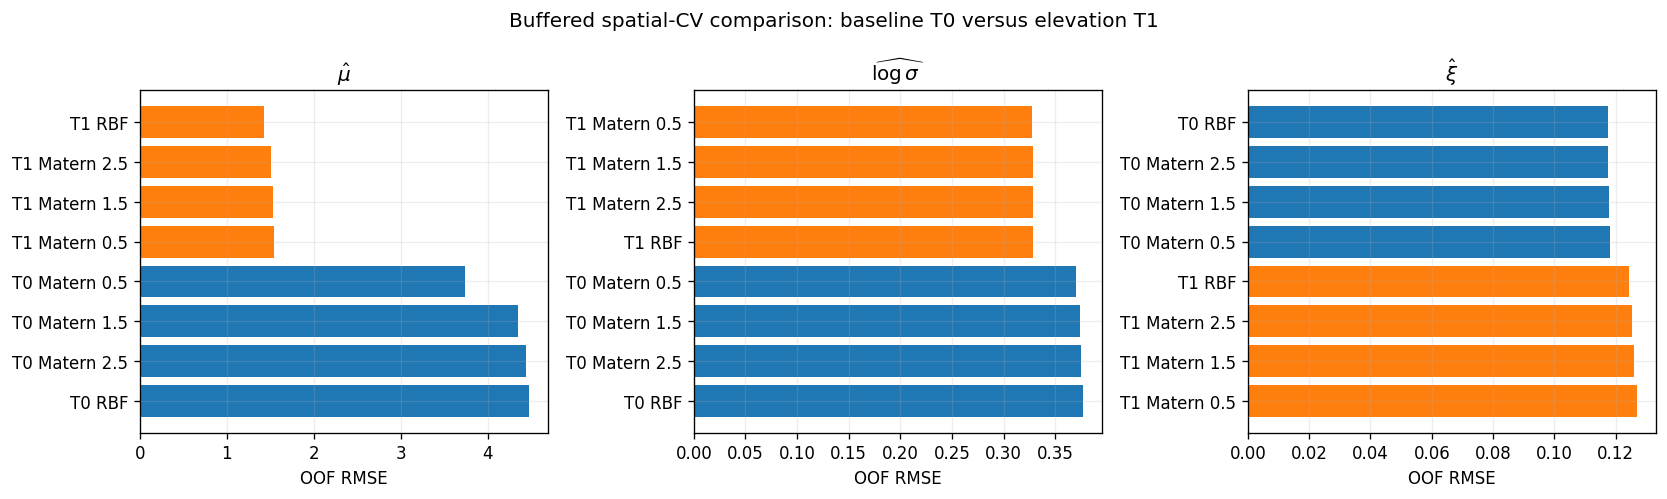

,target,model_id,trend,kernel,nu,RMSE,MAE,Bias,fold_RMSE_sd,mean_retained_train
0,log_sigma,T0_Matern_0p5,T0,Matern,0.5,0.37049,0.27945,-0.04377,0.02829,633.8
1,log_sigma,T1_Matern_0p5,T1,Matern,0.5,0.32711,0.25207,0.01493,0.01818,633.8
2,mu,T0_Matern_0p5,T0,Matern,0.5,3.73450,2.77598,0.70372,1.72458,521.6
3,mu,T1_RBF_na,T1,RBF,NaN,1.42695,1.12311,0.07510,0.49138,521.6
4,xi,T0_RBF_na,T0,RBF,NaN,0.11741,0.09290,0.00110,0.01458,664.0
5,xi,T1_RBF_na,T1,RBF,NaN,0.12432,0.09794,-0.00508,0.01479,664.0


,target,model_id_spatial_cv,trend,kernel,nu,RMSE,MAE,Bias,fold_RMSE_sd,mean_retained_train,model_id_aic,AIC
0,log_sigma,T1_Matern_0p5,T1,Matern,0.5,0.32711,0.25207,0.01493,0.01818,633.8,T1_Matern_1p5,1.20040
1,mu,T1_RBF_na,T1,RBF,NaN,1.42695,1.12311,0.07510,0.49138,521.6,T1_Matern_0p5,1785.40511
2,xi,T0_RBF_na,T0,RBF,NaN,0.11741,0.09290,0.00110,0.01458,664.0,T1_Matern_0p5,-1638.24176


In [9]:
best_overall, best_by_trend, selection_comparison = select_models(
    cv_summary,
    information_criteria,
)

best_overall.to_csv(
    TABLE_DIR / "elevation_gp_selected_models.csv",
    index=False,
    encoding="utf-8-sig",
)
best_by_trend.to_csv(
    TABLE_DIR / "elevation_gp_best_kernel_within_trend.csv",
    index=False,
    encoding="utf-8-sig",
)

cv_figure = plot_cv_comparison(
    cv_summary,
    output_path=FIG_DIR / "elevation_05_spatial_cv_model_comparison.png",
)
plt.show()
display(best_by_trend.round(5))
display(selection_comparison.round(5))

### 參數別高程改善假設檢定

本段只分別回答高程是否改善每一個 GEV parameter，不建立跨三個參數的 family-wise 結論，因此報告 parameter-wise raw p-value，不使用 Holm correction 作主要判斷。

對每個 geographic fold 定義：

$$
D_b=\operatorname{MSE}_{T0,b}-\operatorname{MSE}_{T1,b}.
$$

檢定假設為：

$$
H_0:E(D_b)\leq0,
$$

$$
H_1:E(D_b)>0.
$$

由於只有五個 paired geographic folds，本段使用單尾 exact paired sign-flip test，枚舉全部 32 種符號排列。這是固定 partition 下的 parameter-wise exploratory inference；若要建立 confirmatory evidence，仍需 repeated nested spatial CV。

In [ ]:
parameter_tests, parameter_fold_differences = parameter_wise_elevation_tests(
    fold_metrics=fold_metrics,
    best_by_trend=best_by_trend,
    alpha=0.05,
    output_directory=TABLE_DIR,
)

display(parameter_tests.round(5))
display(parameter_fold_differences.round(5))

### 參數別檢定結果解讀

- location parameter：T1 在 5/5 folds 都降低 MSE，raw p-value 為 0.03125；在未校正的 parameter-wise 0.05 水準下拒絕 H0。
- log-scale parameter：T1 同樣在 5/5 folds 都降低 MSE，raw p-value 為 0.03125；在未校正的 parameter-wise 0.05 水準下拒絕 H0。
- shape parameter：雖然四個 folds 有很小的改善，但另一個 fold 明顯惡化，使 mean MSE difference 為負；raw p-value 為 0.53125，沒有證據支持 T1 改善 shape parameter。
- 以上結果只能形成分別參數的結論，不應改寫成『三個參數整體上具有 family-wise 顯著改善』。

### Block 8 圖表解讀：T0、T1 與 kernel 的最終比較

**橫條圖**

- location parameter 的四個 T1 bars 都明顯短於所有 T0 bars，表示改善主要來自加入高程，而不是只靠更換 kernel。T1 內以 RBF 的 RMSE 最低。
- log-scale parameter 也呈現所有 T1 models 優於所有 T0 models，但 T1 內四種 kernels 的差距很小；最佳為 Matérn 0.5。
- shape parameter 的方向相反：四個 T0 models 均優於四個 T1 models，且 T0 內 kernels 差異很小；最佳為 RBF。

**選模表格**

- Spatial CV 最終選擇：location 使用 T1 + RBF；log-scale 使用 T1 + Matérn 0.5；shape 使用 T0 + RBF。
- AIC 最佳模型分別為 T1 + Matérn 0.5、T1 + Matérn 1.5、T1 + Matérn 0.5，與 Spatial CV 並不完全一致。
- 不一致並不是計算錯誤：AIC 評估樣本內 likelihood，Spatial CV 評估地理留出預測。由於研究目標是空間預測與 return level mapping，後續流程採用 Spatial-CV winner，AIC/BIC 保留為 supporting diagnostics。


## 9. Out-of-fold residual maps

每個 residual 都必須來自「沒有使用該 test fold 訓練」的模型：

$$
e_i=y_i-\hat y_i^{(-\operatorname{fold}(i))}.
$$

如果同號 residual 在地圖上形成大片群聚，代表模型仍有系統性空間偏差。
本步驟比較各 response 最佳 T0 與最佳 T1，檢查加入高程後，
殘差群聚是否縮小。


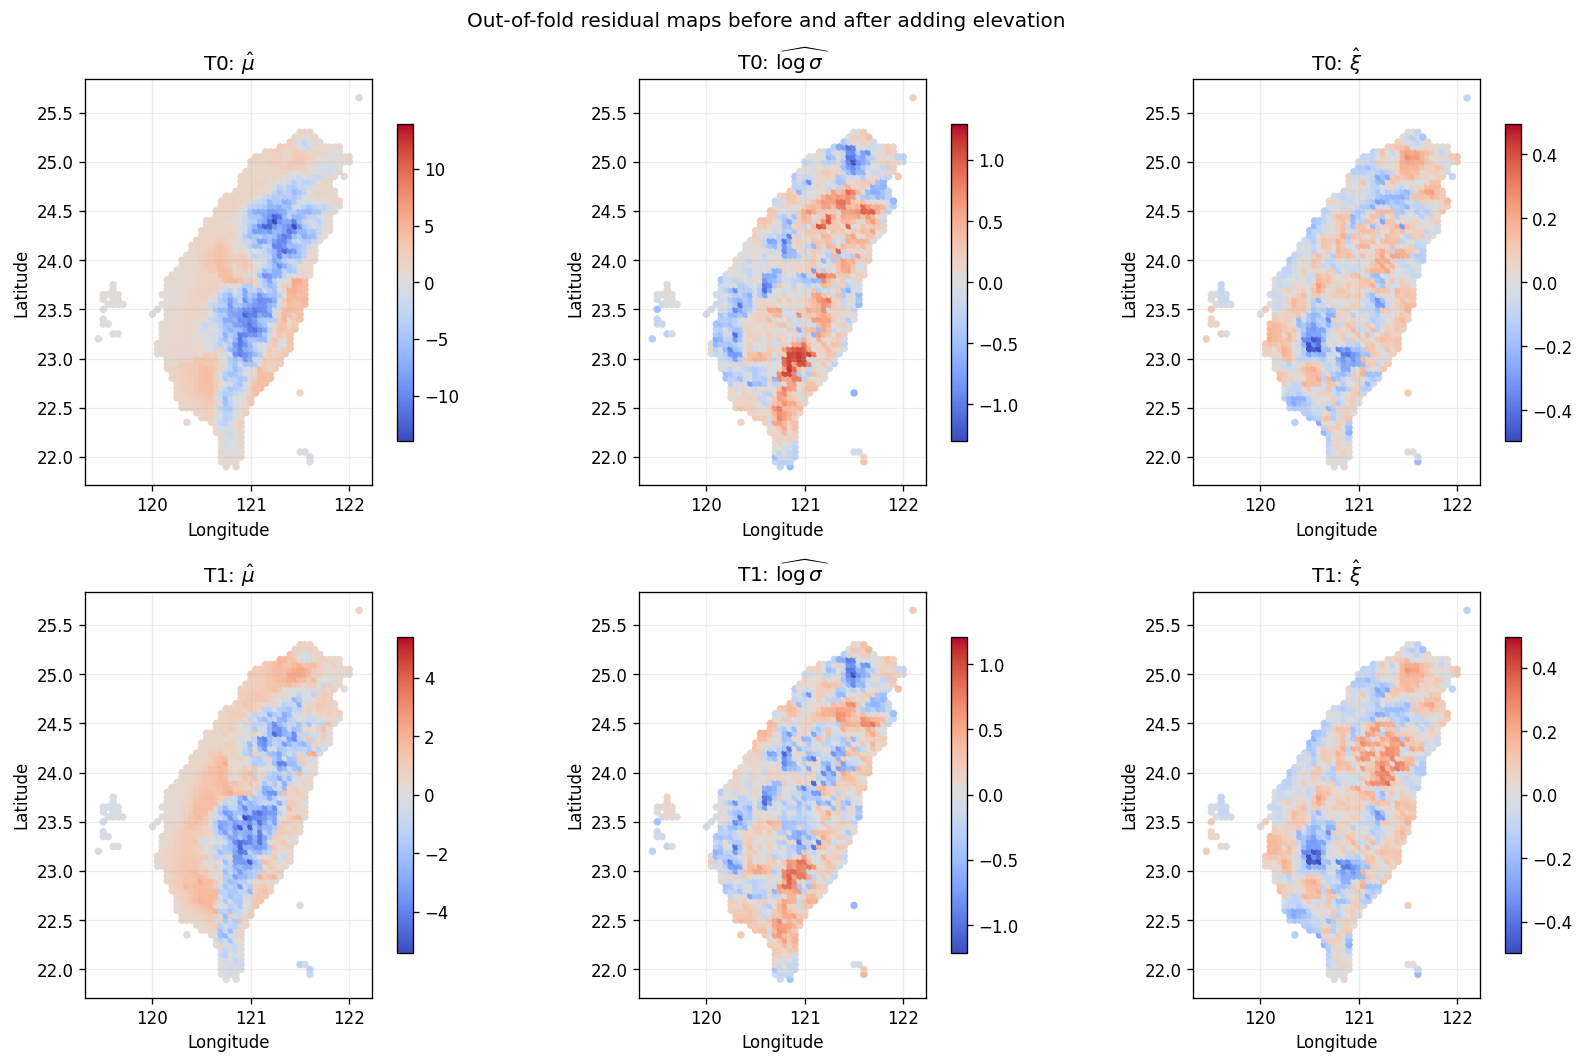

In [10]:
residual_map_figure = plot_oof_residual_maps(
    oof_predictions,
    best_by_trend,
    output_path=FIG_DIR / "elevation_06_oof_residual_maps.png",
)
plt.show()

### Block 9 圖表解讀：Out-of-fold residual maps

- residual 定義為 observed NN-derived parameter 減去 OOF GP prediction；紅色代表模型低估，藍色代表模型高估。
- location parameter：T0 在中央山區形成大範圍負 residual，顯示 coordinate-only GP 將高山與鄰近平地過度平滑。加入高程後，殘差幅度明顯縮小，但中部仍保留連續的同號區塊。
- log-scale parameter：T1 的空間圖形與 T0 相似，但整體誤差略縮小；南部正 residual 與北部／山區負 residual 仍顯示未解釋結構。
- shape parameter：加入高程後，中部及東部出現較明顯的正 residual 群聚，與 Spatial-CV RMSE 變差的結果一致。
- 各 panel 使用自己的 color scale，不能只用顏色深淺直接比較 T0 與 T1 的誤差大小；數值比較必須搭配 RMSE、Moran's I 與 residual variogram。


## 10. Residual Moran's I

Moran's I 使用 projected coordinates 建立 8-nearest-neighbor
空間權重，並以 permutation test 檢查正向 residual spatial
autocorrelation。

判斷標準為：

$$
I>0
$$

表示鄰近 GRID 的 residual 傾向相似；而

$$
p<0.05
$$

表示殘差空間聚集程度高於隨機排列可合理解釋的程度。
若 T1 的 Moran's I 下降，表示高程解釋了一部分原先遺漏的空間結構。
- 若仍顯著，不代表 folds 一定切錯，也可能需要地形、方向性、
  非平穩 covariance 或其他 predictors。


In [11]:
moran_results = calculate_residual_morans_i(
    oof_predictions,
    best_by_trend,
    k=8,
    permutations=MORAN_PERMUTATIONS,
    seed=RANDOM_STATE,
    output_path=TABLE_DIR / "elevation_gp_residual_morans_i.csv",
)
display(moran_results.round(5))

,target,trend,Moran_I,permutation_p,k_neighbors,n_permutations
0,mu,T0,0.85565,0.001,8,999
1,mu,T1,0.77236,0.001,8,999
2,log_sigma,T0,0.60380,0.001,8,999
3,log_sigma,T1,0.53354,0.001,8,999
4,xi,T0,0.56471,0.001,8,999
5,xi,T1,0.60050,0.001,8,999


### Block 10 表格解讀：Residual Moran's I

- location parameter 的 Moran's I 由 0.85565 降至 0.77236；log-scale 由 0.60380 降至 0.53354。加入高程確實減少兩者的 residual spatial clustering，但沒有完全消除。
- shape parameter 的 Moran's I 由 0.56471 增加至 0.60050，表示加入高程後剩餘空間聚集反而更強，支持 shape parameter 保留 T0。
- 六個 permutation p-values 都是 0.001，代表所有 T0／T1 residuals 仍存在顯著正向 spatial autocorrelation。
- 因此正確結論是「高程解釋了 location 與 log-scale 的一部分空間結構」，不能說「加入高程後模型已完整」。後續仍需考慮其他地形 predictors、anisotropy、nonstationarity 或不同 covariance structure。


## 11. Out-of-fold residual variogram

Residual variogram 檢查不同距離下殘差差異是否仍呈現系統性結構。
這裡使用 OOF residual，而不是訓練資料上的 in-sample residual。

比較時應觀察：

- 短距離 semivariance 是否仍明顯偏低；
- T1 是否比 T0 更快進入穩定平台；
- 三個 GEV parameters 是否有不同的殘差空間尺度。

Parameter variogram 用來提出 buffer 候選距離；residual variogram
用來診斷模型剩餘結構，兩者不能混為一談。


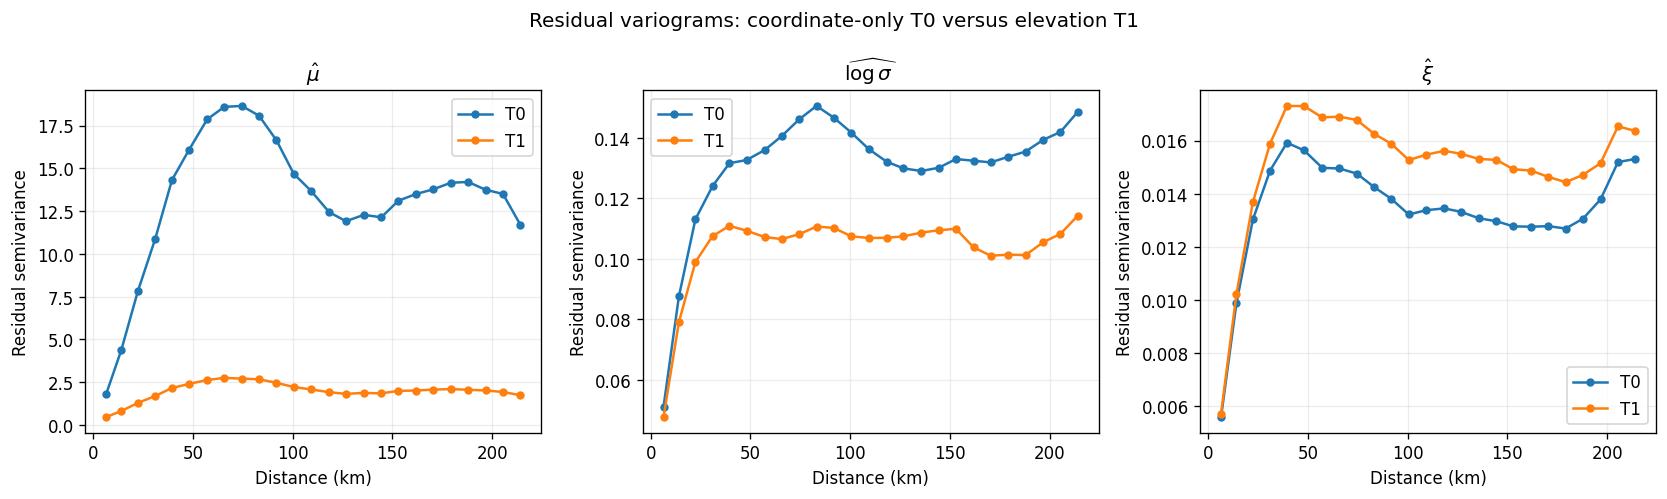

,lag_km,semivariance,n_pairs,target,trend
0,6.412872,1.785066,5293,mu,T0
1,14.115083,4.395606,17415,mu,T0
2,22.390113,7.827670,22383,mu,T0
3,30.994237,10.849825,35191,mu,T0
4,39.461599,14.314045,33476,mu,T0


In [12]:
residual_variograms, residual_variogram_figure = (
    calculate_residual_variograms(
        oof_predictions,
        best_by_trend,
        output_table_path=(
            TABLE_DIR / "elevation_gp_residual_empirical_variograms.csv"
        ),
        output_figure_path=(
            FIG_DIR / "elevation_07_residual_variograms.png"
        ),
    )
)
plt.show()
display(residual_variograms.head())

### Block 11 圖表解讀：Residual variograms

- location parameter：T1 曲線在所有距離都遠低於 T0，短距離 semivariance 與整體平台高度均大幅下降。這是高程改善 location parameter 最清楚的殘差證據。
- log-scale parameter：T1 曲線也普遍低於 T0，表示加入高程降低了剩餘變異；但短距離仍由低值快速上升，說明 local spatial dependence 仍存在。
- shape parameter：T1 曲線大多高於 T0，表示高程沒有減少 residual spatial variation，與 Spatial CV 及 Moran's I 的方向一致。
- 曲線並未在短距離立即變成完全平坦，因此不能宣稱 residual SAC 已消失。這也說明 buffer 只讓驗證更誠實，不能自動修正 GP 模型未解釋的空間結構。


## 12. RL50 與 RL100 的完整流程比較

即使加入高程降低單一參數的 RMSE，也不保證 return level 一定改善，
因為 return level 同時受下列三個參數影響：

$$
\mu,\qquad \sigma,\qquad \xi,
$$

而且對 shape parameter 的誤差特別敏感。

本步驟將三個 OOF parameter predictions 合併，計算：

$$
z_T=
\begin{cases}
\mu+\dfrac{\sigma}{\xi}
\left([-\log(1-1/T)]^{-\xi}-1\right),&\xi\neq0,\\[6pt]
\mu-\sigma\log[-\log(1-1/T)],&\xi=0.
\end{cases}
$$

參考值是 NN-derived GRID parameters 計算的 return level，
因此這裡檢查的是「GP 空間平滑階段」加入高程後是否改善，
不是直接對原始氣溫觀測值進行 return-level 真值驗證。


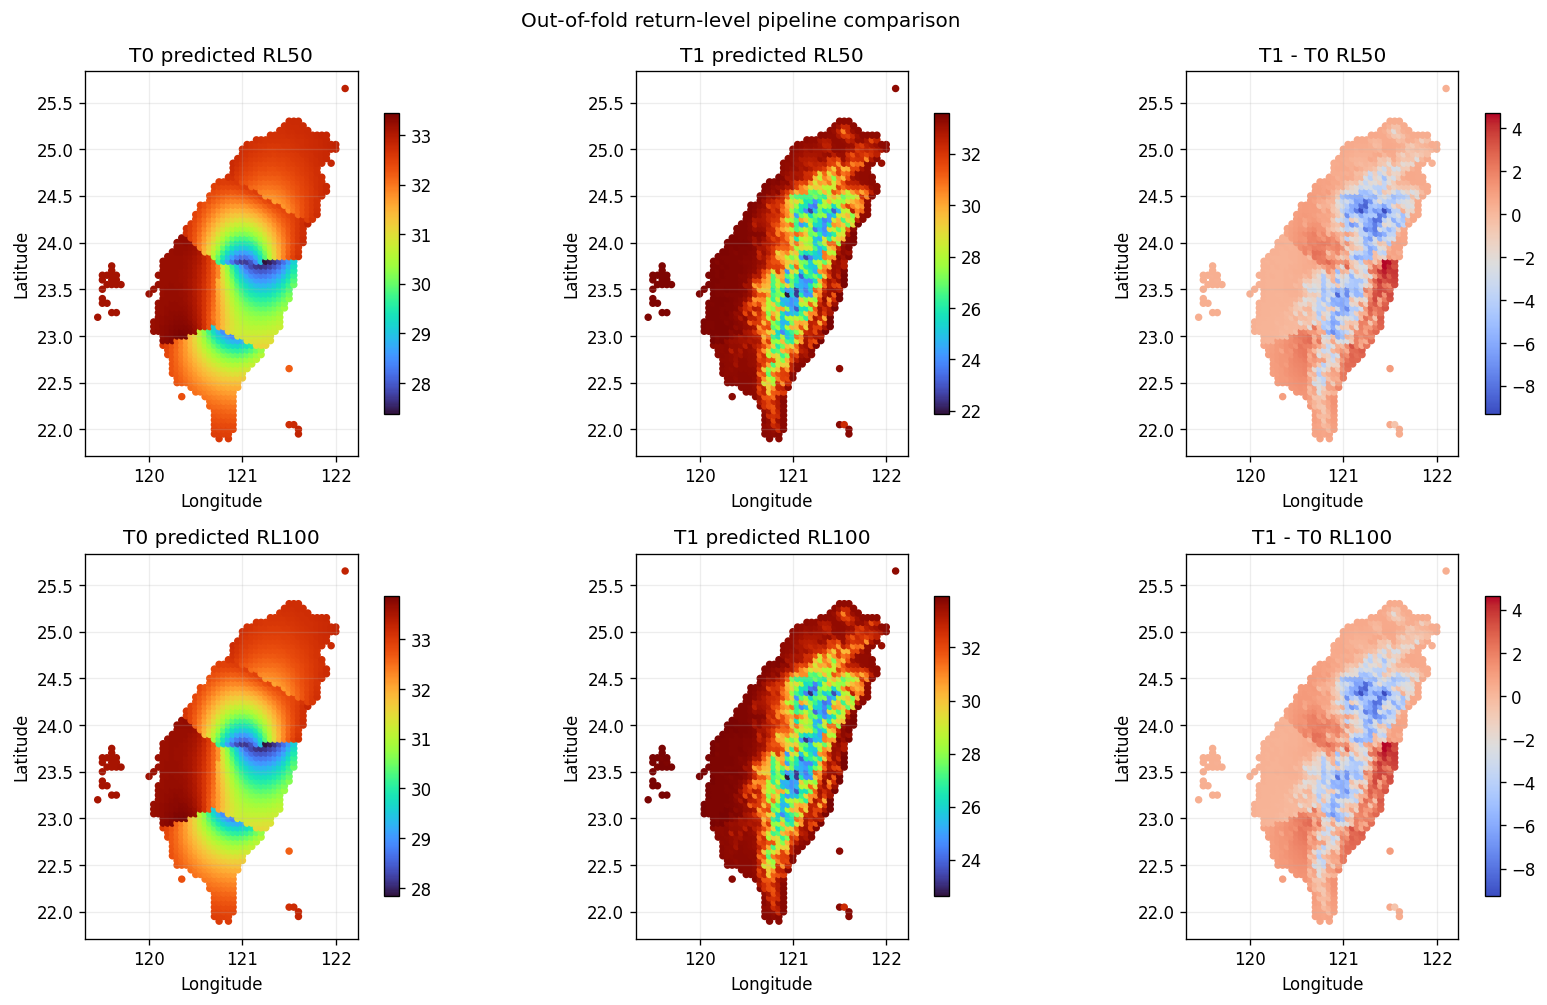

,trend,return_period,RMSE_vs_NN_reference,MAE_vs_NN_reference,Bias_vs_NN_reference,finite_rate
0,T0,50,3.43516,2.52323,0.54853,1.0
1,T0,100,3.38699,2.48949,0.50355,1.0
2,T1,50,1.41942,1.07976,0.01661,1.0
3,T1,100,1.45211,1.09903,-0.01235,1.0


In [13]:
rl_metrics, rl_oof_predictions, return_level_figure = compare_return_levels(
    data=data,
    oof_predictions=oof_predictions,
    best_by_trend=best_by_trend,
    return_periods=(50, 100),
    output_directory=TABLE_DIR,
    output_figure_path=FIG_DIR / "elevation_08_return_level_comparison.png",
)
plt.show()
display(rl_metrics.round(5))

### Return-level pipeline 假設檢定

目前先比較 all-T1 與 all-T0 OOF return-level pipelines。對每個 return period 與 geographic fold 定義：

$$
D_b^{(T)}=\operatorname{MSE}_{T0,b}^{(T)}-\operatorname{MSE}_{T1,b}^{(T)}.
$$

分別對 RL50 與 RL100 檢定：

$$
H_0:E\left(D_b^{(T)}\right)\leq0,
$$

$$
H_1:E\left(D_b^{(T)}\right)>0.
$$

這裡報告各 return period 的 raw p-value。此結果仍是 preliminary all-T1 versus all-T0 comparison；final mixed pipeline 必須在 mixed OOF predictions 建立後重新檢定。

In [ ]:
rl_tests, rl_fold_differences = return_level_pipeline_tests(
    oof_return_levels=rl_oof_predictions,
    baseline_trend="T0",
    candidate_trend="T1",
    alpha=0.05,
    output_directory=TABLE_DIR,
)

display(rl_tests.round(5))
display(rl_fold_differences.round(5))

### Return-level 檢定結果解讀

- RL50：all-T1 在 5/5 folds 都降低 MSE，mean fold MSE difference 為 9.75239，raw p-value 為 0.03125；在 return-period-wise 0.05 水準下拒絕 H0。
- RL100：all-T1 在 5/5 folds 都降低 MSE，mean fold MSE difference 為 9.35963，raw p-value 為 0.03125；在 return-period-wise 0.05 水準下拒絕 H0。
- 這表示目前 all-T1 pipeline 相對 all-T0 pipeline 的 RL 改善在五個 geographic folds 方向一致。
- reference RL 由 NN-derived GRID parameters 計算，因此本檢定驗證的是 GP 空間階段對 NN reference surface 的重建能力，不是已知真實 RL50 或 RL100 的外部真值檢定。
- 最終研究結論仍應改用 T1(mu) + T1(log-sigma) + T0(xi) 的 mixed OOF pipeline 重新計算與檢定。

### Block 12 圖表解讀：RL50 與 RL100

- T0 的 return-level maps 呈現較寬且過度平滑的中央低值區；T1 加入高程後，低值帶更貼近中央山脈，顯示地形訊號成功傳遞到 return-level surface。
- 右欄 difference maps 顯示 T1 相對 T0 在中央高山可降低約 8 至 9 度，在部分平地提高約 1 至 4 度。這不是單純整張地圖平移，而是空間型態被重新分配。
- RL50 RMSE 由 3.43516 降至 1.41942，約改善 58.7%；RL100 RMSE 由 3.38699 降至 1.45211，約改善 57.1%。
- Bias 由約 0.50 至 0.55 降到接近 0，且兩種模型的 finite rate 都是 1.0，表示目前沒有數值發散造成的無限 return level。
- 雖然加入高程使 shape parameter 的單獨預測略差，但 location parameter 的大幅改善主導了目前 RL50／RL100 的整體改善。
- 各 T0 與 T1 map 的 color scale 不完全相同，視覺比較應以右側 difference map 與下方 RMSE／MAE 表為準。
- 這裡的 reference RL 是由 NN-derived GRID parameters 計算，不是未知的真實 return level；因此結果證明的是 GP 空間階段改善，而不是整個 NN + GP pipeline 已對真實極端值完成外部驗證。


## 13. 最終判斷與停止規則

不應只依單一 correlation、AIC 或 residual map 宣稱高程或某一
covariance 結構有效。每個 response 分別依下列順序判斷：

1. Block 4 是否標記 nonlinear mean、anisotropy、nonstationary
   variance/range 或 elevation distance；
2. 所有被標記而有科學意義的候選是否已實作並使用相同 spatial folds；
3. 候選模型的 buffered Spatial-CV RMSE／MAE 是否改善；
4. 改善是否跨 folds 穩定，而非單一區域造成；
5. AIC/BIC 是否支持，或至少沒有強烈反對；
6. OOF residual map、Moran's I 與 variogram 是否改善；
7. RL50、RL100 的 OOF error 與 finite rate 是否改善。

### 可宣稱「模型足夠」的停止條件

只有同時符合下列條件才停止增加模型：

- 沒有尚未處理的 diagnostic flags；或相應擴充經 spatial CV 證明
  沒有穩定、實質改善；
- OOF residual 不再呈現可解釋的方向性、高程分層或區域性 pattern；
- prediction interval coverage 與誤差符合研究目的；
- 複雜模型的改善未超過 fold-to-fold uncertainty 時，保留簡單模型；
- covariance parameters 不在邊界且能穩定估計。

### 目前核心比較的既有結果

- location parameter：在目前八個核心候選中，T1 + RBF 的
  Spatial-CV 表現最佳。
- log-scale parameter：在目前八個核心候選中，T1 + Matérn 0.5
  表現最佳。
- shape parameter：在目前八個核心候選中，T0 + RBF 表現最佳。
- 全 T1 pipeline 的 RL50、RL100 優於全 T0，但正式結果仍應另算
  T1 location + T1 log-scale + T0 shape 的 mixed pipeline。
- 既有最佳模型的 residual Moran's I 仍顯著，故目前只能說
  「高程是重要但不充分的 predictor」。

上述結論必須和 Block 5 的 `candidate_plan` 一起解讀。若表中仍有
`required extension`，核心 winner 只能稱為「目前已實作候選中的最佳
模型」，不能稱為空間結構已充分建模。

正式論文版本建議使用 repeated spatial partitions 或 nested spatial CV：
inner loop 選 kernel、predictor、buffer 與 covariance structure，
outer loop 才報告最終地理泛化誤差，避免同一組 folds 同時選模及報告。
